In [131]:
import sys
from pathlib import Path

import importlib.util

spec = importlib.util.spec_from_file_location("asdm", Path(str(Path.cwd().resolve().parent / 'src'/ 'asdm' / 'asdm.py')))
asdm = importlib.util.module_from_spec(spec)
spec.loader.exec_module(asdm)
sys.modules['asdm'] = asdm

# sys.path.append(str(Path.cwd().resolve().parent / 'src'))

from asdm import Parser, Solver, sdmodel

import networkx as nx
import matplotlib.pyplot as plt

### Example 1: Parsing a simple expression

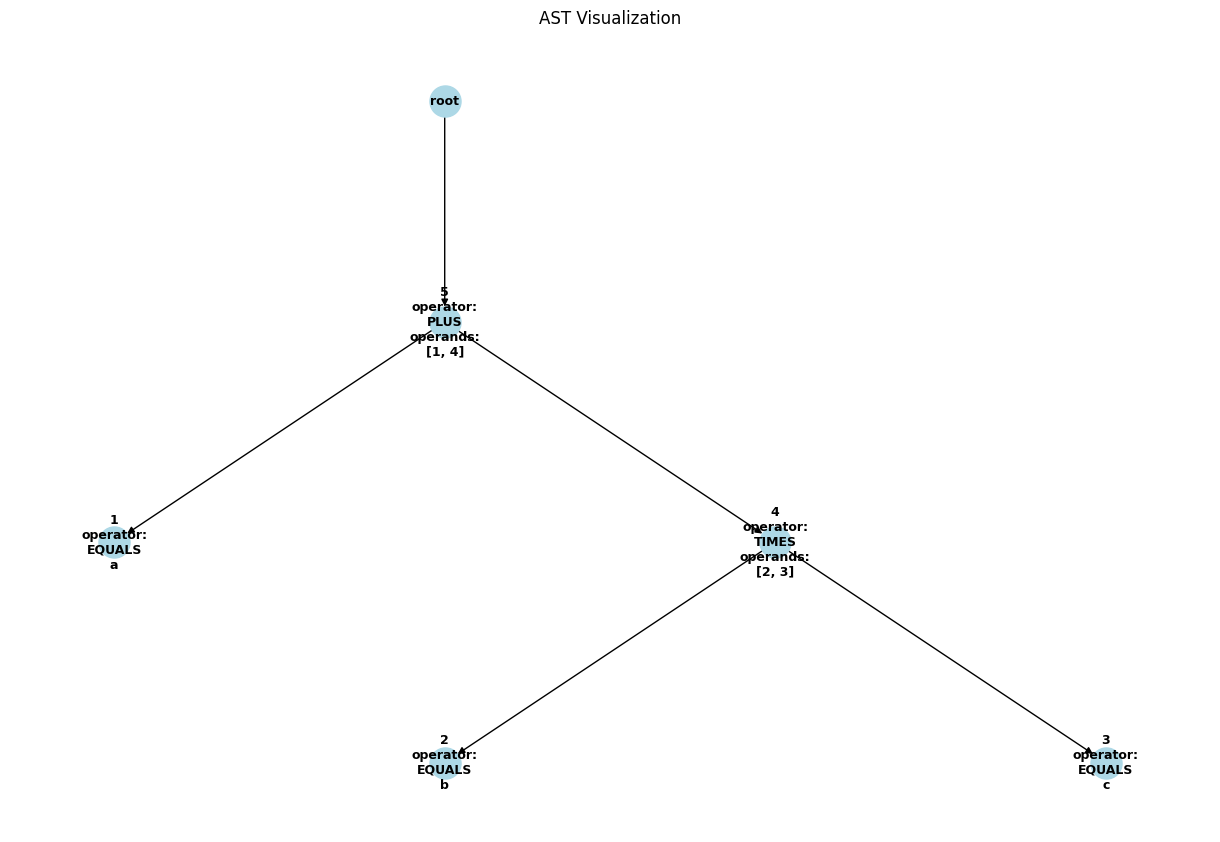

In [132]:
parser = Parser()
expression = "a + b * c" # an example expression taken from the World3 model
ast = parser.parse(expression, plot=True)

### Example 2: Parsing a complex expression

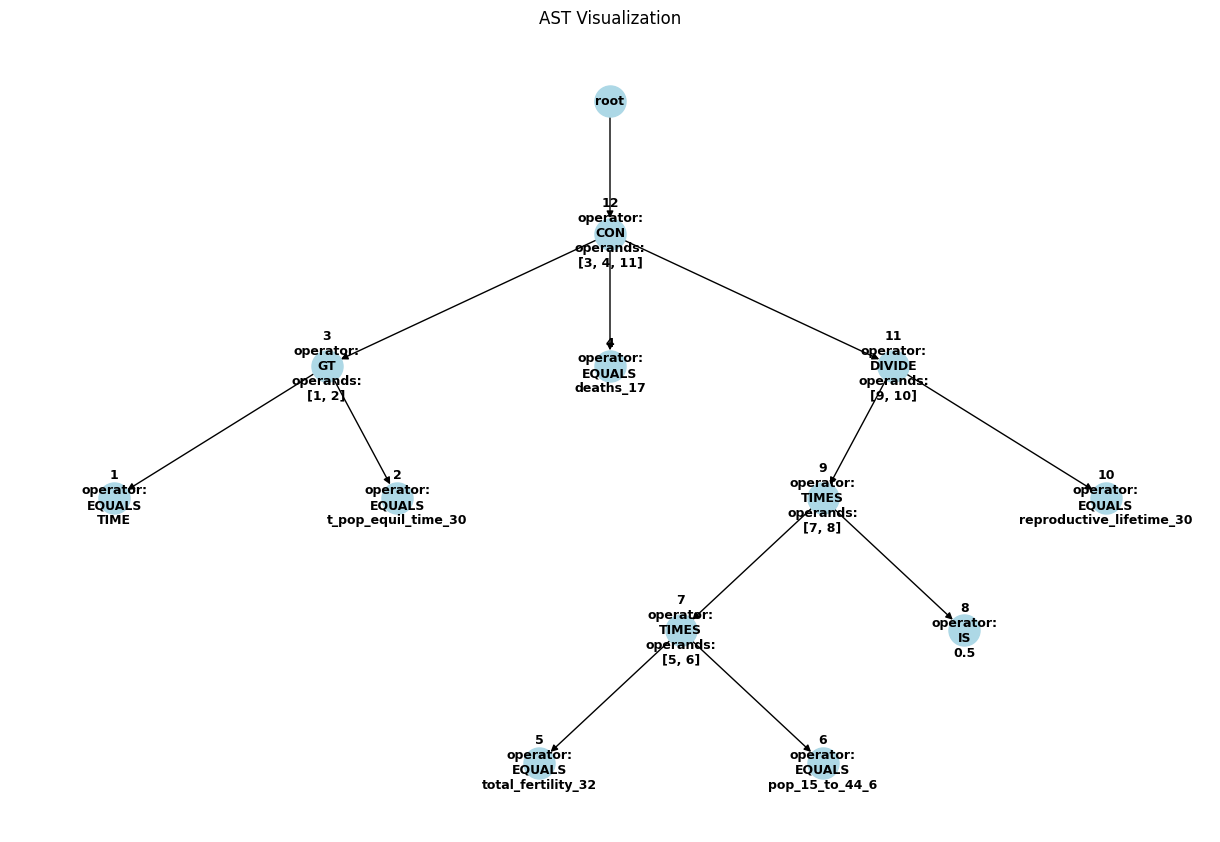

In [133]:
parser = Parser()
expression = "IF ( TIME > t_pop_equil_time_30) THEN deaths_17 ELSE (total_fertility_32*pop_15_to_44_6*0.5/reproductive_lifetime_30)" # an example expression taken from the World3 model
ast = parser.parse(expression, plot=True)

### Example 3: Creating the dependent graph of a variable

In [134]:
# model_file = Path.cwd().resolve().parent / 'resources' / 'World3.stmx'
model_file = Path.cwd().resolve().parent / 'resources' / 'SIRSocialVariousInterventions.stmx'
model = sdmodel(model_file)

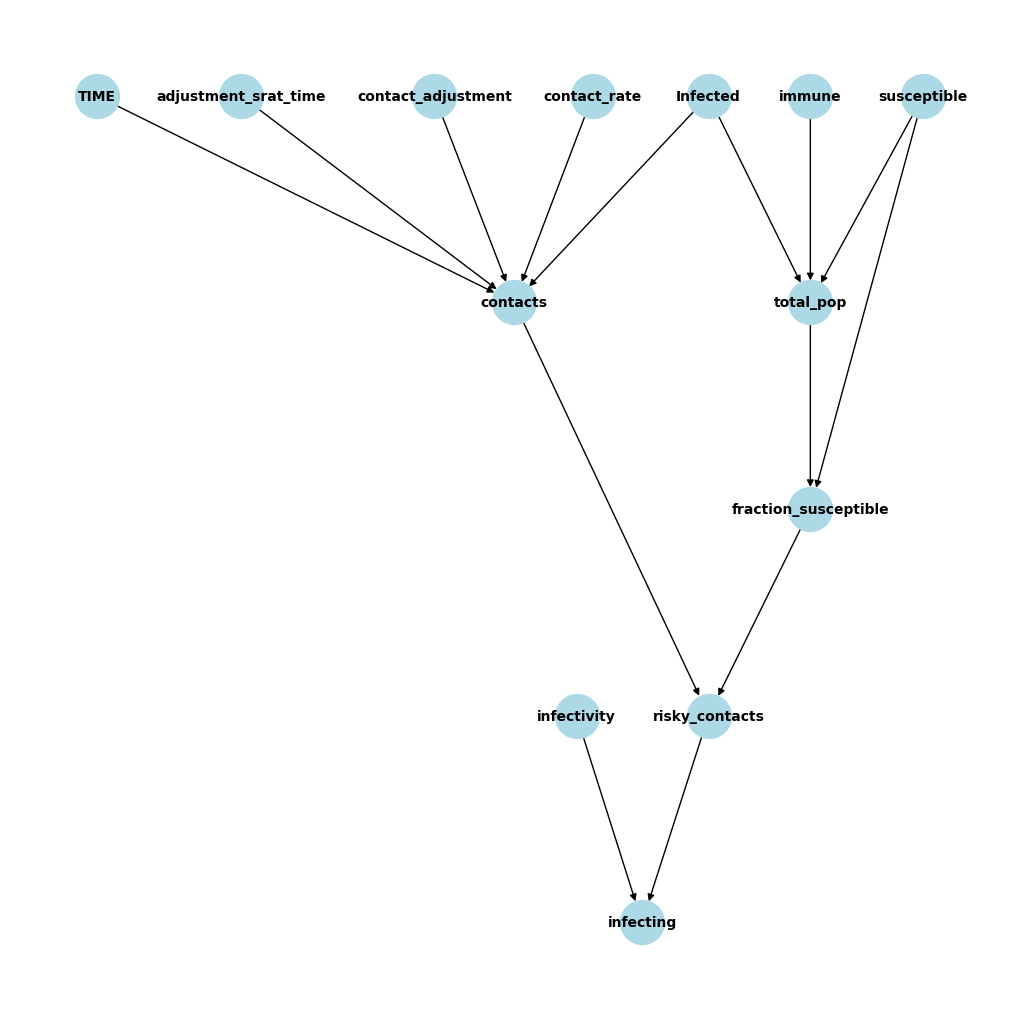

In [135]:
# dep_graph = model.create_variable_dependency_graph(var='labor_force_80')
# dep_graph = model.create_variable_dependency_graph(var='total_fertility_32')
dep_graph = model.create_variable_dependency_graph(var='infecting')

pos = nx.nx_agraph.graphviz_layout(dep_graph, prog="dot")

fig = plt.figure(figsize=(10, 10))
nx.draw(
    dep_graph, 
    pos, 
    labels={node[0]: node[0] for node in dep_graph.nodes(data=True)}, 
    with_labels=True, 
    node_size=1000, 
    node_color='lightblue', 
    font_size=10, 
    font_weight='bold', 
    arrows=True)

### Example 4: Creating full dependent graph

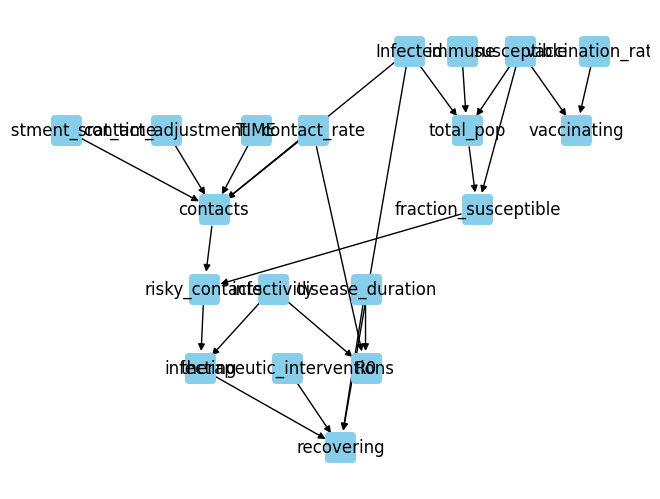

In [136]:
cld = model.generate_full_dependent_graph(show='iter')


### Example 5: Creating a CLD

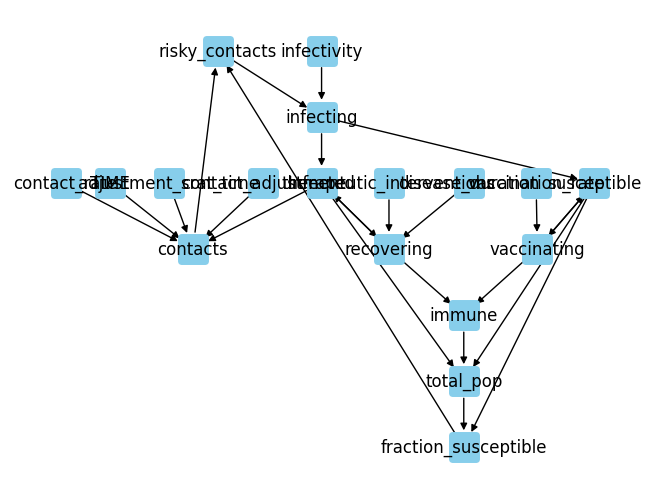

In [137]:
cld = model.generate_cld(show=True, loop=True)